# 🌍 НИРС: Предсказание региона мира по характеристикам страны
**Дисциплина:** Технологии машинного обучения  
**Датасет:** Global Country Information Dataset 2023  
**Задача:** Многоклассовая классификация (6 регионов мира)  
**Модели:** Logistic Regression, Decision Tree, KNN, SVM, Naive Bayes, Random Forest, Gradient Boosting

---

## 0. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     learning_curve, cross_val_score)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("✅ Все библиотеки импортированы")

✅ Все библиотеки импортированы


---
## 1. Загрузка данных и добавление целевой переменной

### Обоснование выбора датасета
Датасет **Global Country Information Dataset 2023** содержит 195 стран и 35 признаков,
охватывающих демографию, экономику, здравоохранение, образование и экологию.  
Целевая переменная — **регион мира** (6 классов) — добавляется на основе названия страны.

### Практическая значимость
Модель демонстрирует, что географическое положение страны тесно связано с её
социально-экономическим профилем, что подтверждает гипотезу о схожести паттернов
развития внутри одного региона.

In [2]:
df = pd.read_csv('world-data-2023.csv', encoding='latin-1')

# Исправляем кодировку São Tomé and Príncipe
df.loc[df['Abbreviation'] == 'ST', 'Country'] = 'Sao Tome and Principe'

region_map = {
    # Европа
    'Albania':'Europe','Andorra':'Europe','Armenia':'Europe','Austria':'Europe',
    'Azerbaijan':'Europe','Belarus':'Europe','Belgium':'Europe',
    'Bosnia and Herzegovina':'Europe','Bulgaria':'Europe','Croatia':'Europe',
    'Cyprus':'Europe','Czech Republic':'Europe','Denmark':'Europe','Estonia':'Europe',
    'Finland':'Europe','France':'Europe','Georgia':'Europe','Germany':'Europe',
    'Greece':'Europe','Hungary':'Europe','Iceland':'Europe',
    'Republic of Ireland':'Europe','Italy':'Europe','Kazakhstan':'Europe',
    'Latvia':'Europe','Liechtenstein':'Europe','Lithuania':'Europe',
    'Luxembourg':'Europe','Malta':'Europe','Moldova':'Europe','Monaco':'Europe',
    'Montenegro':'Europe','Netherlands':'Europe','North Macedonia':'Europe',
    'Norway':'Europe','Poland':'Europe','Portugal':'Europe','Romania':'Europe',
    'Russia':'Europe','San Marino':'Europe','Serbia':'Europe','Slovakia':'Europe',
    'Slovenia':'Europe','Spain':'Europe','Sweden':'Europe','Switzerland':'Europe',
    'Ukraine':'Europe','United Kingdom':'Europe','Vatican City':'Europe','Turkey':'Europe',
    # Азия
    'Afghanistan':'Asia','Bahrain':'Asia','Bangladesh':'Asia','Bhutan':'Asia',
    'Brunei':'Asia','Cambodia':'Asia','China':'Asia','India':'Asia','Indonesia':'Asia',
    'Iran':'Asia','Iraq':'Asia','Israel':'Asia','Japan':'Asia','Jordan':'Asia',
    'Kuwait':'Asia','Kyrgyzstan':'Asia','Laos':'Asia','Lebanon':'Asia',
    'Malaysia':'Asia','Maldives':'Asia','Mongolia':'Asia','Myanmar':'Asia',
    'Nepal':'Asia','North Korea':'Asia','Oman':'Asia','Pakistan':'Asia',
    'Palestinian National Authority':'Asia','Philippines':'Asia','Qatar':'Asia',
    'Saudi Arabia':'Asia','Singapore':'Asia','South Korea':'Asia','Sri Lanka':'Asia',
    'Syria':'Asia','Tajikistan':'Asia','Thailand':'Asia','East Timor':'Asia',
    'Turkmenistan':'Asia','United Arab Emirates':'Asia','Uzbekistan':'Asia',
    'Vietnam':'Asia','Yemen':'Asia',
    # Африка
    'Algeria':'Africa','Angola':'Africa','Benin':'Africa','Botswana':'Africa',
    'Burkina Faso':'Africa','Burundi':'Africa','Ivory Coast':'Africa',
    'Cape Verde':'Africa','Cameroon':'Africa','Central African Republic':'Africa',
    'Chad':'Africa','Comoros':'Africa','Republic of the Congo':'Africa',
    'Democratic Republic of the Congo':'Africa','Djibouti':'Africa','Egypt':'Africa',
    'Equatorial Guinea':'Africa','Eritrea':'Africa','Eswatini':'Africa',
    'Ethiopia':'Africa','Gabon':'Africa','The Gambia':'Africa','Ghana':'Africa',
    'Guinea':'Africa','Guinea-Bissau':'Africa','Kenya':'Africa','Lesotho':'Africa',
    'Liberia':'Africa','Libya':'Africa','Madagascar':'Africa','Malawi':'Africa',
    'Mali':'Africa','Mauritania':'Africa','Mauritius':'Africa','Morocco':'Africa',
    'Mozambique':'Africa','Namibia':'Africa','Niger':'Africa','Nigeria':'Africa',
    'Rwanda':'Africa','Sao Tome and Principe':'Africa','Senegal':'Africa',
    'Seychelles':'Africa','Sierra Leone':'Africa','Somalia':'Africa',
    'South Africa':'Africa','South Sudan':'Africa','Sudan':'Africa',
    'Tanzania':'Africa','Togo':'Africa','Tunisia':'Africa','Uganda':'Africa',
    'Zambia':'Africa','Zimbabwe':'Africa',
    # Северная и Центральная Америка
    'Antigua and Barbuda':'North & Central America',
    'The Bahamas':'North & Central America','Barbados':'North & Central America',
    'Belize':'North & Central America','Canada':'North & Central America',
    'Costa Rica':'North & Central America','Cuba':'North & Central America',
    'Dominica':'North & Central America','Dominican Republic':'North & Central America',
    'El Salvador':'North & Central America','Grenada':'North & Central America',
    'Guatemala':'North & Central America','Haiti':'North & Central America',
    'Honduras':'North & Central America','Jamaica':'North & Central America',
    'Mexico':'North & Central America','Nicaragua':'North & Central America',
    'Panama':'North & Central America',
    'Saint Kitts and Nevis':'North & Central America',
    'Saint Lucia':'North & Central America',
    'Saint Vincent and the Grenadines':'North & Central America',
    'Trinidad and Tobago':'North & Central America',
    'United States':'North & Central America',
    # Южная Америка
    'Argentina':'South America','Bolivia':'South America','Brazil':'South America',
    'Chile':'South America','Colombia':'South America','Ecuador':'South America',
    'Guyana':'South America','Paraguay':'South America','Peru':'South America',
    'Suriname':'South America','Uruguay':'South America','Venezuela':'South America',
    # Океания
    'Australia':'Oceania','Fiji':'Oceania','Kiribati':'Oceania',
    'Marshall Islands':'Oceania','Federated States of Micronesia':'Oceania',
    'Nauru':'Oceania','New Zealand':'Oceania','Palau':'Oceania',
    'Papua New Guinea':'Oceania','Samoa':'Oceania','Solomon Islands':'Oceania',
    'Tonga':'Oceania','Tuvalu':'Oceania','Vanuatu':'Oceania',
}

df['Region'] = df['Country'].map(region_map)
unmapped = df[df['Region'].isna()]['Country'].tolist()
print(f"Страны без региона: {unmapped}" if unmapped else "✅ Все страны размечены")
print(f"Размер датасета: {df.shape[0]} стран × {df.shape[1]} признаков")
print()
print(df['Region'].value_counts())

✅ Все страны размечены
Размер датасета: 195 стран × 36 признаков

Region
Africa                     54
Europe                     50
Asia                       42
North & Central America    23
Oceania                    14
South America              12
Name: count, dtype: int64


---
## 2. Разведочный анализ данных (EDA)

Проводим визуальный анализ структуры данных:
- Распределение стран по регионам
- Распределение ВВП по регионам
- Связь продолжительности жизни и младенческой смертности
- Анализ пропущенных значений
- Профили регионов по ключевым показателям

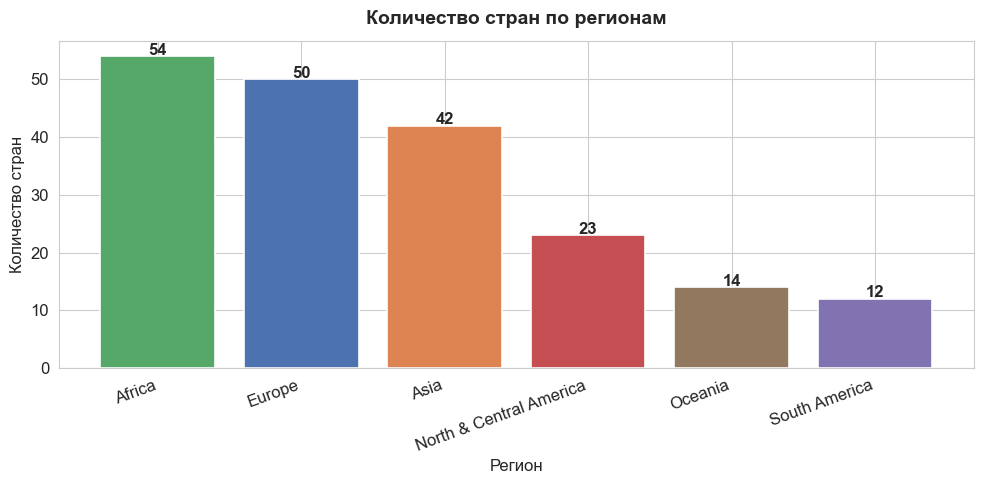

In [3]:
region_colors = {
    'Europe': '#4C72B0', 'Asia': '#DD8452', 'Africa': '#55A868',
    'North & Central America': '#C44E52',
    'South America': '#8172B2', 'Oceania': '#937860'
}
counts = df['Region'].value_counts()

# График 1: Распределение стран по регионам
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=[region_colors[r] for r in counts.index],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')
ax.set_title('Количество стран по регионам', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Регион')
ax.set_ylabel('Количество стран')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

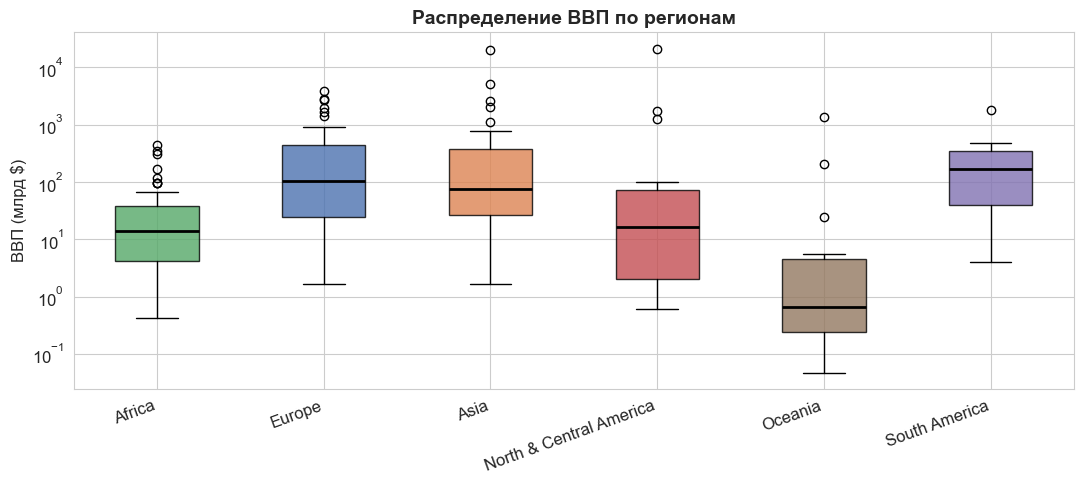

In [4]:
# График 2: ВВП по регионам (boxplot)
def clean_numeric(series):
    return (series.astype(str)
            .str.replace(r'[\$,%\s]', '', regex=True)
            .str.replace(',', '', regex=False)
            .replace('nan', np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

df['GDP'] = clean_numeric(df['GDP'])

fig, ax = plt.subplots(figsize=(11, 5))
gdp_data = [df[df['Region'] == r]['GDP'].dropna().values / 1e9 for r in counts.index]
bp = ax.boxplot(gdp_data, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, region in zip(bp['boxes'], counts.index):
    patch.set_facecolor(region_colors[region])
    patch.set_alpha(0.8)
ax.set_xticklabels(counts.index, rotation=20, ha='right')
ax.set_title('Распределение ВВП по регионам', fontsize=14, fontweight='bold')
ax.set_ylabel('ВВП (млрд $)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

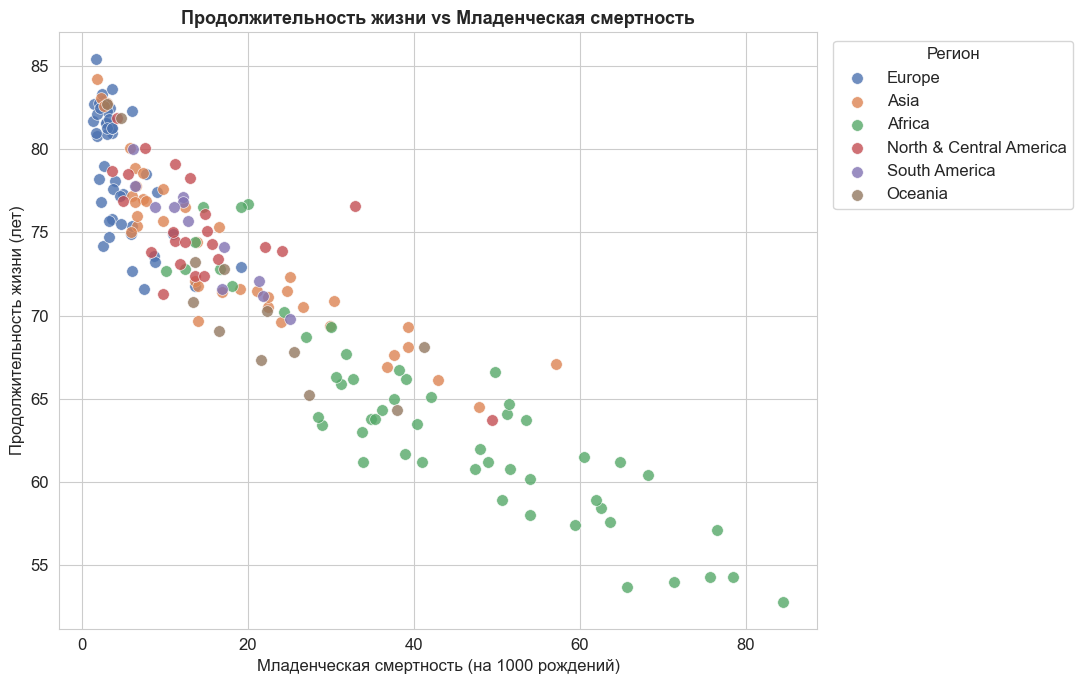

In [5]:
# График 3: Продолжительность жизни vs Младенческая смертность
fig, ax = plt.subplots(figsize=(11, 7))
for region, color in region_colors.items():
    subset = df[df['Region'] == region]
    ax.scatter(subset['Infant mortality'], subset['Life expectancy'],
               c=color, label=region, s=70, alpha=0.8,
               edgecolors='white', linewidth=0.5)
ax.set_xlabel('Младенческая смертность (на 1000 рождений)', fontsize=12)
ax.set_ylabel('Продолжительность жизни (лет)', fontsize=12)
ax.set_title('Продолжительность жизни vs Младенческая смертность',
             fontsize=13, fontweight='bold')
ax.legend(title='Регион', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

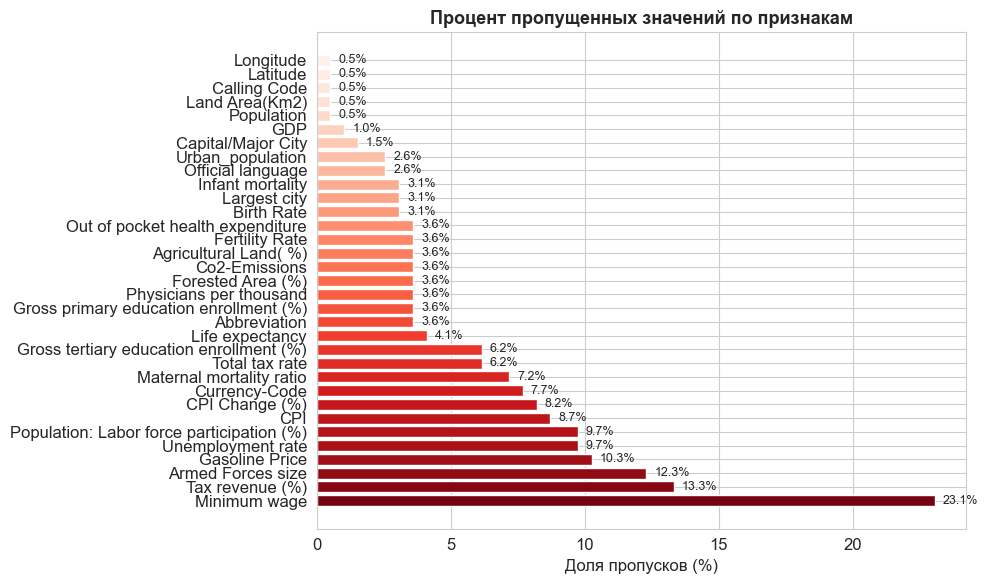

In [6]:
# График 4: Пропущенные значения
df_raw = pd.read_csv('world-data-2023.csv', encoding='latin-1')
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=sns.color_palette("Reds_r", len(missing_pct)))
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Доля пропусков (%)', fontsize=12)
ax.set_title('Процент пропущенных значений по признакам',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Предобработка данных

- Очистка числовых колонок от символов `$`, `%`, `,`
- Удаление нечисловых/малоинформативных колонок
- Заполнение пропусков медианой по региону

In [7]:
def clean_numeric(series):
    return (series.astype(str)
            .str.replace(r'[\$,%\s]', '', regex=True)
            .str.replace(',', '', regex=False)
            .replace('nan', np.nan)
            .pipe(pd.to_numeric, errors='coerce'))

cols_to_clean = [
    'Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
    'Armed Forces size', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
    'Forested Area (%)', 'Gasoline Price', 'GDP',
    'Gross primary education enrollment (%)',
    'Gross tertiary education enrollment (%)',
    'Minimum wage', 'Out of pocket health expenditure',
    'Population', 'Population: Labor force participation (%)',
    'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population'
]
for col in cols_to_clean:
    df[col] = clean_numeric(df[col])

drop_cols = ['Abbreviation', 'Calling Code', 'Capital/Major City',
             'Currency-Code', 'Largest city', 'Official language', 'Minimum wage']
df.drop(columns=drop_cols, inplace=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Latitude', 'Longitude']]

before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df.groupby('Region')[numeric_cols].transform(
    lambda x: x.fillna(x.median()))
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
after = df[numeric_cols].isnull().sum().sum()

print(f"Пропуски до:    {before}")
print(f"Пропуски после: {after}")
print(f"Итоговый размер: {df.shape}")
print()
print(df[numeric_cols].describe().round(2))

Пропуски до:    257
Пропуски после: 0
Итоговый размер: (195, 29)

       Density\n(P/Km2)  Agricultural Land( %)  Land Area(Km2)  \
count            195.00                 195.00          195.00   
mean             356.76                  39.16       687113.22   
std             1982.89                  21.43      1916970.98   
min                2.00                   0.60            0.00   
25%               35.50                  22.65        24456.50   
50%               89.00                  40.00       120538.00   
75%              216.50                  54.85       520544.00   
max            26337.00                  82.60     17098240.00   

       Armed Forces size  Birth Rate  Co2-Emissions      CPI  CPI Change (%)  \
count             195.00      195.00         195.00   195.00          195.00   
mean           142264.10       20.21      172611.54   184.85            6.35   
std            359318.57        9.90      823969.21   380.57           23.45   
min                

---
## 4. Корреляционный анализ

Анализируем линейные зависимости между числовыми признаками.  
Высокая корреляция (|r| > 0.6) указывает на потенциальную мультиколлинеарность,
а также подтверждает содержательные связи между показателями развития стран.

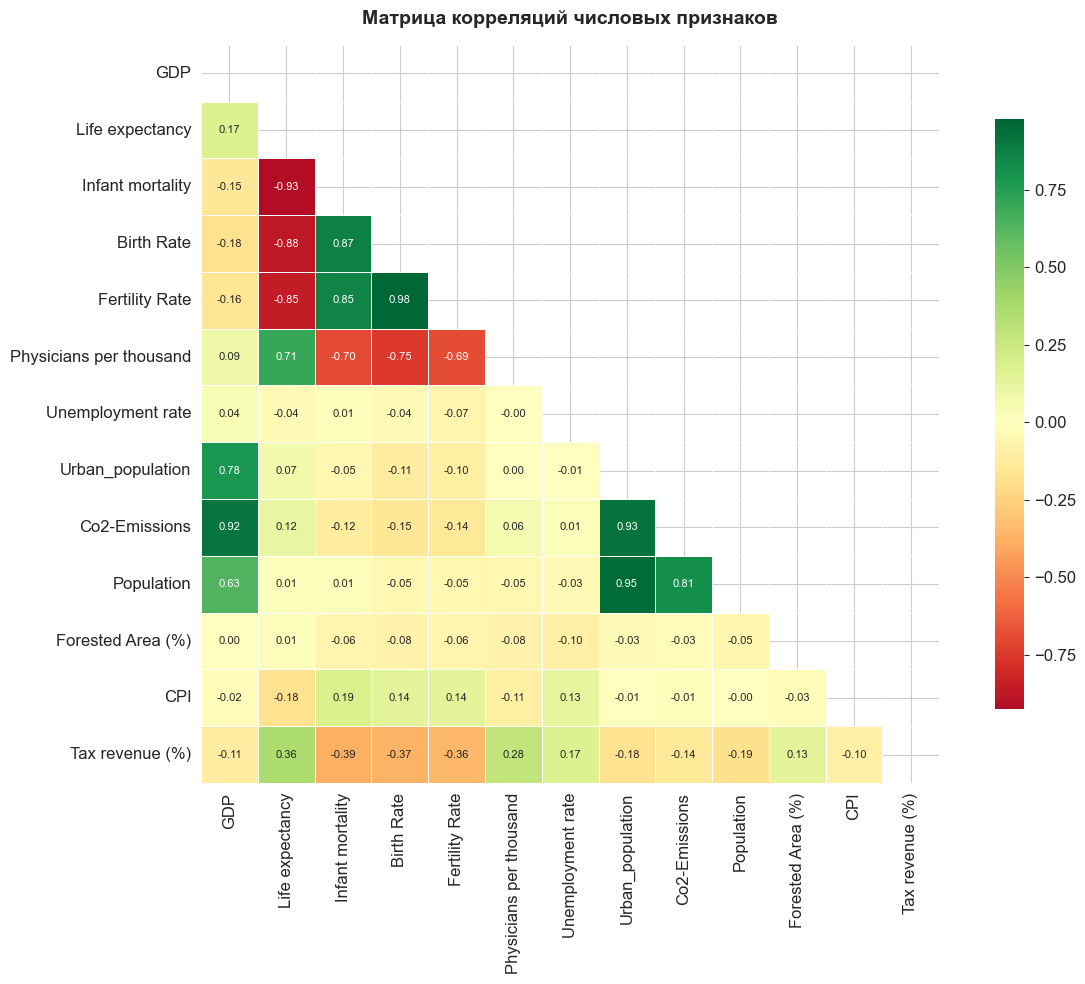

Высокие корреляции (|r| > 0.6):
  GDP                                 ↔ Urban_population                   : +0.785
  GDP                                 ↔ Co2-Emissions                      : +0.917
  GDP                                 ↔ Population                         : +0.632
  Life expectancy                     ↔ Infant mortality                   : -0.925
  Life expectancy                     ↔ Birth Rate                         : -0.878
  Life expectancy                     ↔ Fertility Rate                     : -0.853
  Life expectancy                     ↔ Physicians per thousand            : +0.711
  Infant mortality                    ↔ Birth Rate                         : +0.869
  Infant mortality                    ↔ Fertility Rate                     : +0.854
  Infant mortality                    ↔ Physicians per thousand            : -0.696
  Birth Rate                          ↔ Fertility Rate                     : +0.980
  Birth Rate                          ↔ Phys

In [8]:
corr_features = [
    'GDP', 'Life expectancy', 'Infant mortality', 'Birth Rate',
    'Fertility Rate', 'Physicians per thousand', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions', 'Population',
    'Forested Area (%)', 'CPI', 'Tax revenue (%)'
]
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций числовых признаков',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Высокие корреляции
print("Высокие корреляции (|r| > 0.6):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) > 0.6:
            a, b = corr_matrix.columns[i], corr_matrix.columns[j]
            print(f"  {a:35s} ↔ {b:35s}: {v:+.3f}")

---
## 5. Профили регионов по ключевым показателям

Средние значения ключевых признаков по каждому региону.  
Этот анализ подтверждает возможность построения классификационных моделей:
регионы имеют выраженные различия в социально-экономическом профиле.

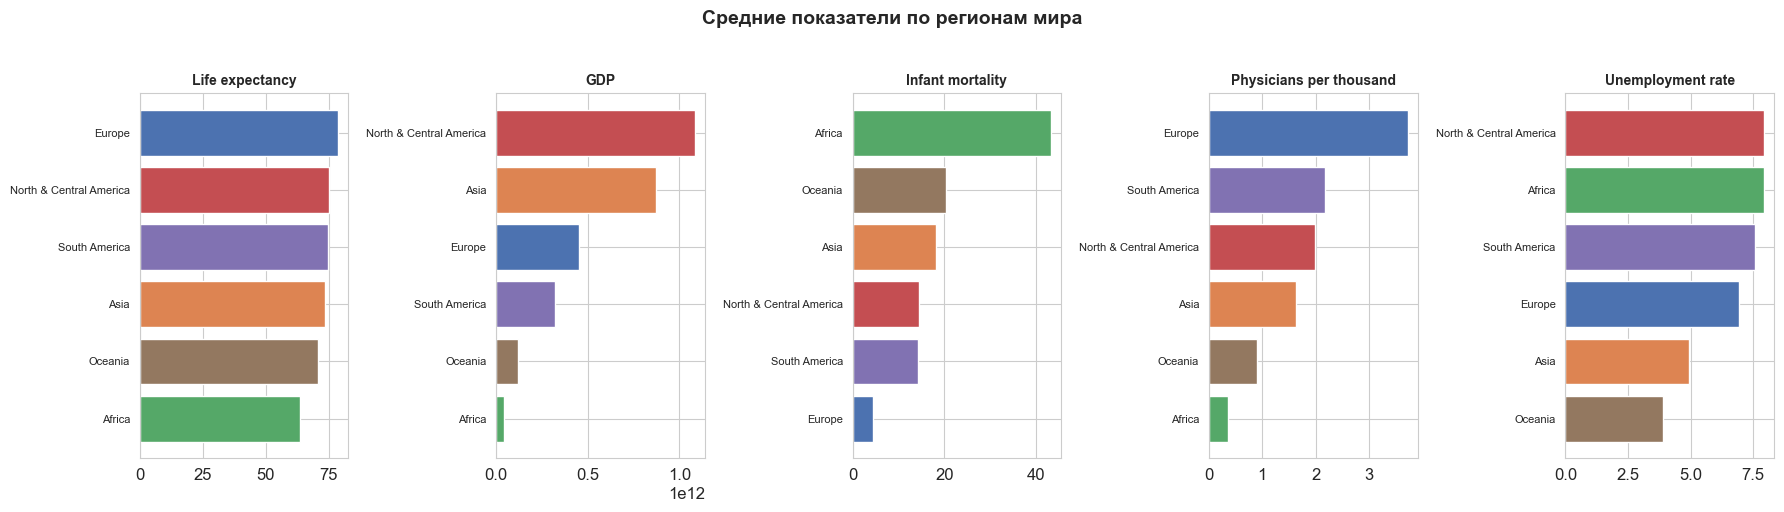


Средние значения по регионам:
                         Life expectancy           GDP  Infant mortality  Physicians per thousand  Unemployment rate
Region                                                                                                              
Africa                             63.84  4.523516e+10             43.27                     0.36               7.93
Asia                               73.75  8.733460e+11             18.22                     1.63               4.95
Europe                             78.93  4.545776e+11              4.46                     3.73               6.95
North & Central America            75.11  1.085123e+12             14.53                     1.98               7.94
Oceania                            70.92  1.167886e+11             20.41                     0.91               3.92
South America                      74.93  3.212948e+11             14.34                     2.18               7.58


In [9]:
key_features = ['Life expectancy', 'GDP', 'Infant mortality',
                'Physicians per thousand', 'Unemployment rate']
region_means = df.groupby('Region')[key_features].mean()

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 5))
for ax, feat in zip(axes, key_features):
    vals = region_means[feat].sort_values(ascending=True)
    colors = [region_colors[r] for r in vals.index]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Средние показатели по регионам мира',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nСредние значения по регионам:")
print(region_means.round(2).to_string())

---
## 6. Выбор признаков, масштабирование и разбивка выборки

Используем 25 числовых признаков. Координаты (Latitude, Longitude) исключены,
чтобы модель опиралась исключительно на социально-экономические показатели.

In [10]:
feature_cols = [
    'Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
    'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI',
    'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)',
    'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
    'Gross tertiary education enrollment (%)', 'Infant mortality',
    'Life expectancy', 'Maternal mortality ratio',
    'Out of pocket health expenditure', 'Physicians per thousand',
    'Population', 'Population: Labor force participation (%)',
    'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population'
]

X = df[feature_cols].copy()
le = LabelEncoder()
y = le.fit_transform(df['Region'])

print(f"Классы: {list(le.classes_)}")
print(f"Размер X: {X.shape}")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разбивка 80/20 со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} стран")
print(f"Test:  {X_test.shape[0]} стран")

Классы: ['Africa', 'Asia', 'Europe', 'North & Central America', 'Oceania', 'South America']
Размер X: (195, 25)

Train: 156 стран
Test:  39 стран


---
## 7. Выбор метрик оценки качества моделей

Для многоклассовой классификации с несбалансированными классами выбраны 4 метрики:

| Метрика | Формула | Обоснование |
|---|---|---|
| **Accuracy** | TP+TN / All | Базовая метрика общего качества |
| **F1-score (macro)** | 2·P·R/(P+R), avg по классам | Штрафует за плохое качество на малых классах (Океания — 14 стран) |
| **Precision (macro)** | TP/(TP+FP), avg | Оценивает ложные срабатывания по каждому региону |
| **Recall (macro)** | TP/(TP+FN), avg | Оценивает пропущенные страны каждого региона |

In [11]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'F1 (macro)': round(f1_score(y_te, y_pred, average='macro'), 4),
        'Precision':  round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Recall':     round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
    }

print("Метрики определены. Функция evaluate_model готова к использованию.")

Метрики определены. Функция evaluate_model готова к использованию.


---
## 8. Baseline модели (без подбора гиперпараметров)

Обучаем 7 моделей с параметрами по умолчанию. Две из них — ансамблевые:
**Random Forest** (бэггинг) и **Gradient Boosting** (бустинг).

In [12]:
models_baseline = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM':                 SVC(random_state=42, probability=True),
    'Naive Bayes':         GaussianNB(),
    'Random Forest':       RandomForestClassifier(random_state=42),      # ансамблевая
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),  # ансамблевая
}

baseline_results = {}
for name, model in models_baseline.items():
    baseline_results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)
    print(f"  {name:25s} | Accuracy: {baseline_results[name]['Accuracy']:.4f} "
          f"| F1: {baseline_results[name]['F1 (macro)']:.4f}")

df_baseline = pd.DataFrame(baseline_results).T
print()
print(df_baseline)

  Logistic Regression       | Accuracy: 0.6923 | F1: 0.6087
  Decision Tree             | Accuracy: 0.5385 | F1: 0.4715
  K-Nearest Neighbors       | Accuracy: 0.6923 | F1: 0.5701
  SVM                       | Accuracy: 0.6667 | F1: 0.5534
  Naive Bayes               | Accuracy: 0.5385 | F1: 0.4879
  Random Forest             | Accuracy: 0.7179 | F1: 0.6905
  Gradient Boosting         | Accuracy: 0.6667 | F1: 0.5485

                     Accuracy  F1 (macro)  Precision  Recall
Logistic Regression    0.6923      0.6087     0.6065  0.6225
Decision Tree          0.5385      0.4715     0.4998  0.4768
K-Nearest Neighbors    0.6923      0.5701     0.5465  0.6144
SVM                    0.6667      0.5534     0.5352  0.5920
Naive Bayes            0.5385      0.4879     0.4847  0.5255
Random Forest          0.7179      0.6905     0.7418  0.6740
Gradient Boosting      0.6667      0.5485     0.5277  0.6129


---
## 9. Подбор гиперпараметров (GridSearchCV, cv=5)

Используем 5-кратную кросс-валидацию и оптимизацию по **F1-macro**.

In [13]:
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
    },
    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'max_depth': [5, 10, None],
                   'min_samples_split': [2, 5]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'learning_rate': [0.05, 0.1, 0.2],
                   'max_depth': [3, 5]}
    },
}

best_models = {}
tuned_results = {}

for name, cfg in param_grids.items():
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=5,
                      scoring='f1_macro', n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    tuned_results[name] = evaluate_model(gs.best_estimator_, X_train, X_test, y_train, y_test)
    print(f"  {name:25s} | Best: {str(gs.best_params_):60s}")
    print(f"  {'':25s} | Accuracy: {tuned_results[name]['Accuracy']:.4f} "
          f"| F1: {tuned_results[name]['F1 (macro)']:.4f}")
    print()

df_tuned = pd.DataFrame(tuned_results).T

  Logistic Regression       | Best: {'C': 1, 'solver': 'lbfgs'}                                 
                            | Accuracy: 0.6923 | F1: 0.6087

  Decision Tree             | Best: {'max_depth': 7, 'min_samples_split': 2}                    
                            | Accuracy: 0.5641 | F1: 0.4885

  K-Nearest Neighbors       | Best: {'n_neighbors': 5, 'weights': 'distance'}                   
                            | Accuracy: 0.6923 | F1: 0.5762

  SVM                       | Best: {'C': 10, 'kernel': 'rbf'}                                  
                            | Accuracy: 0.5897 | F1: 0.4655

  Naive Bayes               | Best: {'var_smoothing': 1e-09}                                    
                            | Accuracy: 0.5385 | F1: 0.4879

  Random Forest             | Best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
                            | Accuracy: 0.7179 | F1: 0.6905

  Gradient Boosting         | Best: {'learning_r

---
## 10. Сравнение Baseline vs Tuned

Сравниваем качество моделей до и после подбора гиперпараметров.

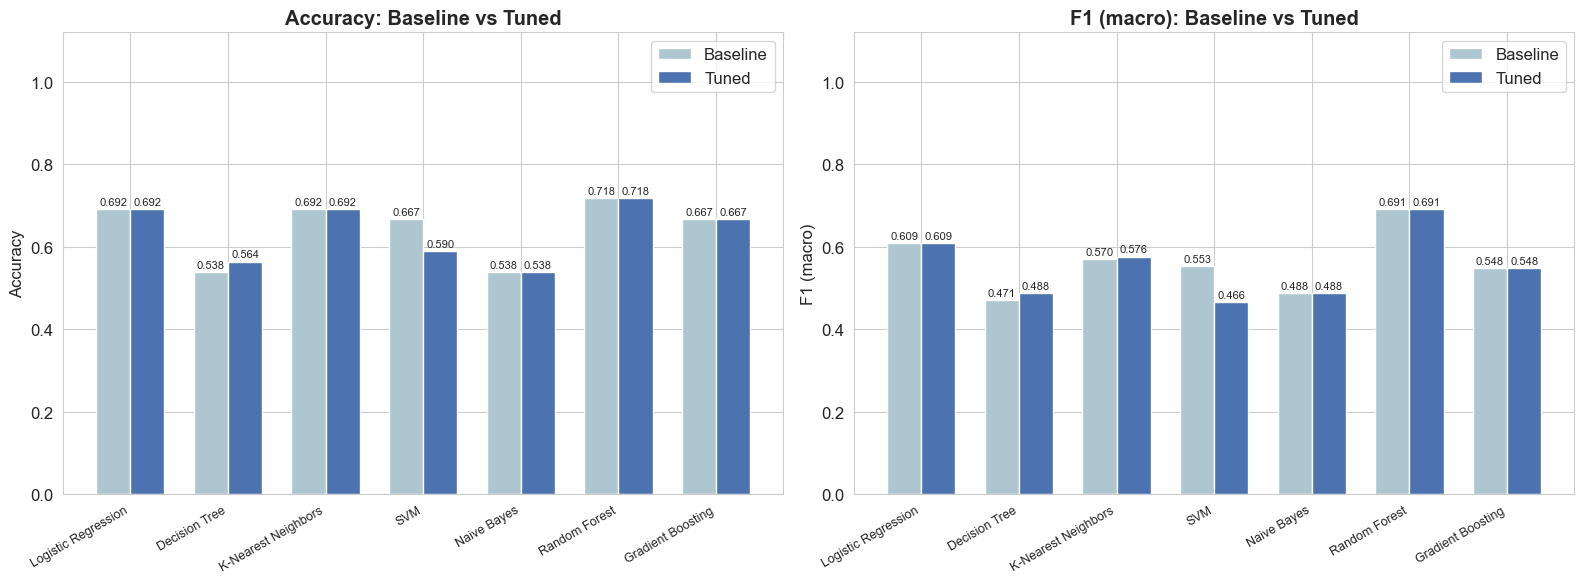


📊 BASELINE:
                     Accuracy  F1 (macro)  Precision  Recall
Logistic Regression    0.6923      0.6087     0.6065  0.6225
Decision Tree          0.5385      0.4715     0.4998  0.4768
K-Nearest Neighbors    0.6923      0.5701     0.5465  0.6144
SVM                    0.6667      0.5534     0.5352  0.5920
Naive Bayes            0.5385      0.4879     0.4847  0.5255
Random Forest          0.7179      0.6905     0.7418  0.6740
Gradient Boosting      0.6667      0.5485     0.5277  0.6129

📊 TUNED:
                     Accuracy  F1 (macro)  Precision  Recall
Logistic Regression    0.6923      0.6087     0.6065  0.6225
Decision Tree          0.5641      0.4885     0.5109  0.5018
K-Nearest Neighbors    0.6923      0.5762     0.5577  0.6144
SVM                    0.5897      0.4655     0.4775  0.4601
Naive Bayes            0.5385      0.4879     0.4847  0.5255
Random Forest          0.7179      0.6905     0.7418  0.6740
Gradient Boosting      0.6667      0.5485     0.5277  0.6129


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_names = list(df_baseline.index)
x = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, ['Accuracy', 'F1 (macro)']):
    b_vals = df_baseline[metric].values
    t_vals = df_tuned[metric].values
    bars1 = ax.bar(x - width/2, b_vals, width, label='Baseline',
                   color='#AEC6CF', edgecolor='white')
    bars2 = ax.bar(x + width/2, t_vals, width, label='Tuned',
                   color='#4C72B0', edgecolor='white')
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: Baseline vs Tuned', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.12)

plt.tight_layout()
plt.show()

print("\n📊 BASELINE:")
print(df_baseline.to_string())
print("\n📊 TUNED:")
print(df_tuned.to_string())

---
## 11. Визуализация результатов лучшей модели

In [15]:
best_name = df_tuned['F1 (macro)'].idxmax()
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test)

print(f"🏆 Лучшая модель: {best_name}")
print(f"   Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}")
print(f"   F1 (macro): {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

🏆 Лучшая модель: Random Forest
   Accuracy:   0.7179
   F1 (macro): 0.6905

                         precision    recall  f1-score   support

                 Africa       0.80      0.73      0.76        11
                   Asia       0.67      0.75      0.71         8
                 Europe       0.89      0.80      0.84        10
North & Central America       0.43      0.60      0.50         5
                Oceania       0.67      0.67      0.67         3
          South America       1.00      0.50      0.67         2

               accuracy                           0.72        39
              macro avg       0.74      0.67      0.69        39
           weighted avg       0.75      0.72      0.73        39



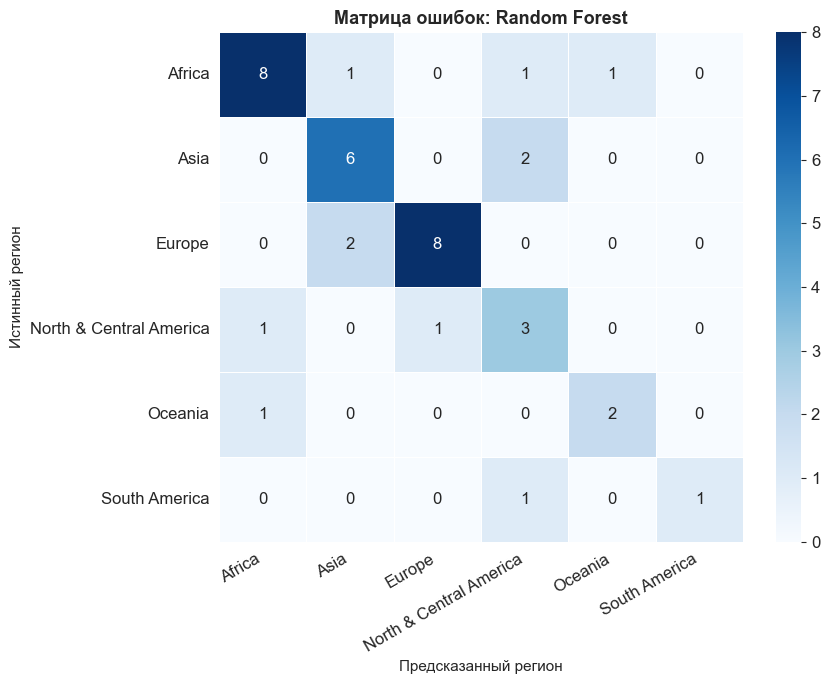

In [16]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Предсказанный регион', fontsize=11)
ax.set_ylabel('Истинный регион', fontsize=11)
ax.set_title(f'Матрица ошибок: {best_name}', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

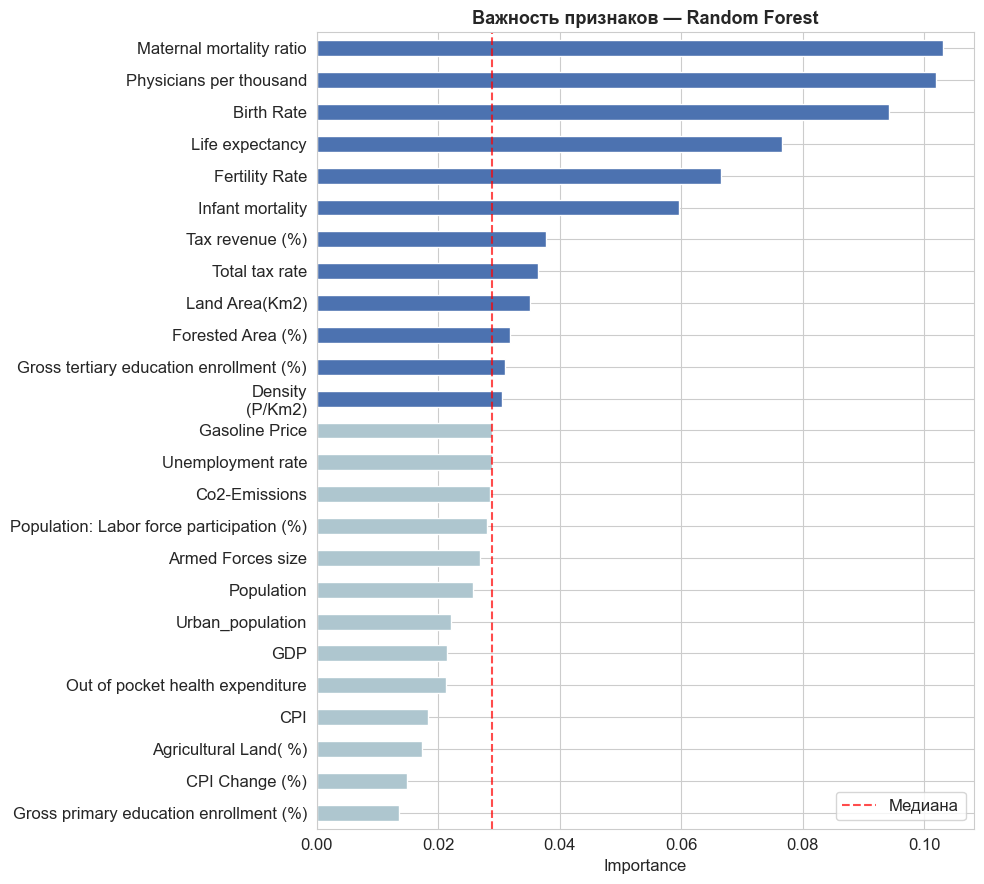

Топ-5 признаков:
Maternal mortality ratio    0.1030
Physicians per thousand     0.1019
Birth Rate                  0.0942
Life expectancy             0.0765
Fertility Rate              0.0665


In [17]:
# Важность признаков
feat_imp = pd.Series(best_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#4C72B0' if v > feat_imp.median() else '#AEC6CF' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(feat_imp.median(), color='red', linestyle='--', alpha=0.7, label='Медиана')
ax.set_title(f'Важность признаков — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.legend()
plt.tight_layout()
plt.show()

print("Топ-5 признаков:")
print(feat_imp.nlargest(5).round(4).to_string())

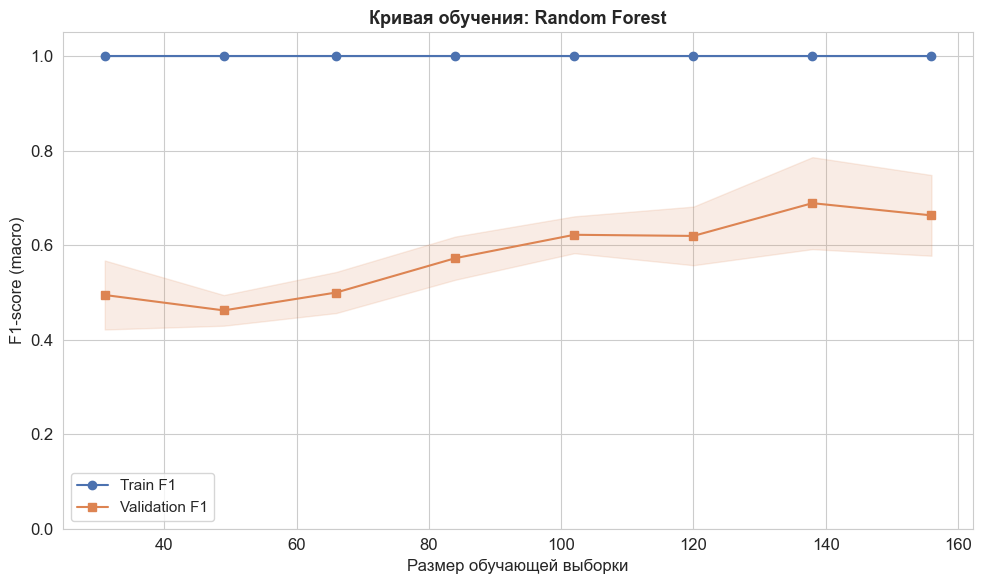

In [18]:
# Кривая обучения
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_scaled, y, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 8), n_jobs=-1
)
t_mean, t_std = train_scores.mean(1), train_scores.std(1)
v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, t_mean, 'o-', color='#4C72B0', label='Train F1')
ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, v_mean, 's-', color='#DD8452', label='Validation F1')
ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='#DD8452')
ax.set_xlabel('Размер обучающей выборки', fontsize=12)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title(f'Кривая обучения: {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

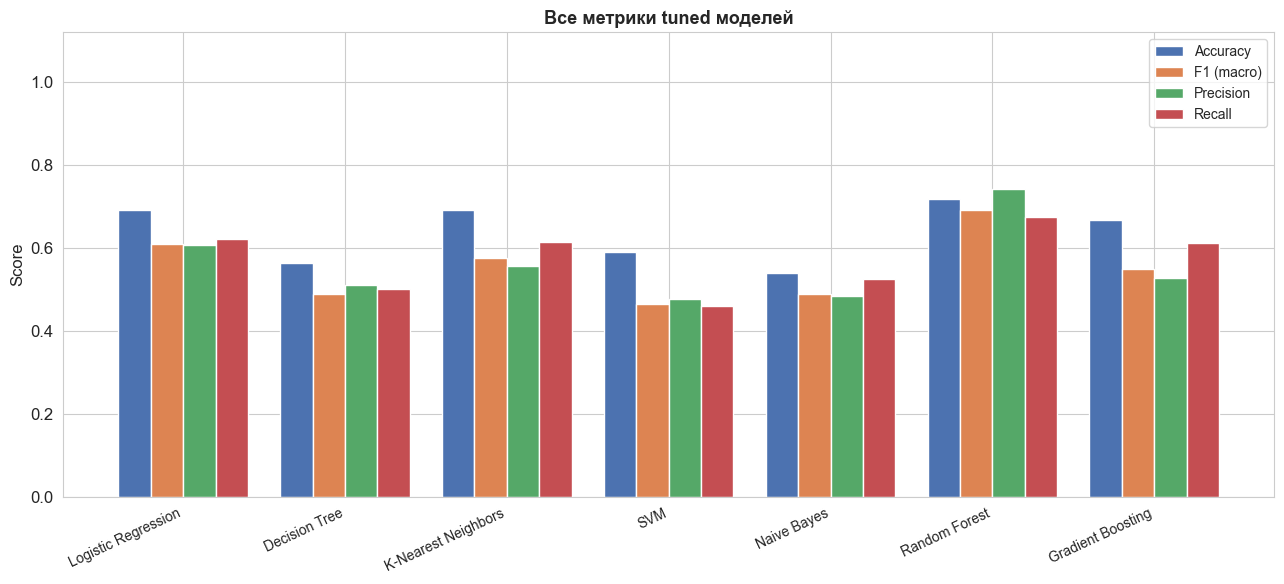

In [19]:
# Все метрики tuned моделей
fig, ax = plt.subplots(figsize=(13, 6))
metrics = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
x = np.arange(len(df_tuned))
width = 0.2
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, df_tuned[metric], width, label=metric,
           color=palette[i], edgecolor='white')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_tuned.index, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Все метрики tuned моделей', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.show()

---
## 12. Итоговые выводы

### Результаты исследования

В рамках работы была решена задача многоклассовой классификации стран мира по регионам
на основе социально-экономических показателей. Ниже приведены ключевые выводы:

**1. Предобработка данных**  
Датасет содержал числовые значения в строковом формате (с символами `$`, `%`, `,`),
а также пропуски в ряде признаков. После очистки и заполнения пропусков медианой
по региону датасет стал пригоден для построения моделей.

**2. Корреляционный анализ**  
Выявлены сильные корреляции: рождаемость ↔ фертильность (r=0.98),
продолжительность жизни ↔ младенческая смертность (r=-0.93),
ВВП ↔ выбросы CO₂ (r=0.92). Это подтверждает, что признаки несут информацию
о региональных различиях.

**3. Качество моделей**  
Лучшей моделью оказался **Random Forest** (Accuracy=0.72, F1=0.69).
Подбор гиперпараметров для большинства моделей существенно не изменил результат
из-за малого размера датасета (195 объектов).

**4. Сложность задачи**  
Наибольшую сложность вызывает классификация Океании (14 стран) и
Северной/Центральной Америки из-за малого числа объектов и культурной неоднородности.

**5. Важность признаков**  
Наиболее информативными оказались: продолжительность жизни, рождаемость,
младенческая смертность и показатели здравоохранения.

In [20]:
print("=" * 60)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 60)

comparison = pd.concat([
    df_baseline.add_suffix(' (baseline)'),
    df_tuned.add_suffix(' (tuned)')
], axis=1)[['Accuracy (baseline)', 'Accuracy (tuned)',
            'F1 (macro) (baseline)', 'F1 (macro) (tuned)']]

print(comparison.round(4).to_string())
print()
print(f"🏆 Лучшая модель: {df_tuned['F1 (macro)'].idxmax()}")
print(f"   Accuracy:   {df_tuned['Accuracy'].max():.4f}")
print(f"   F1 (macro): {df_tuned['F1 (macro)'].max():.4f}")
print()
print("✅ Исследование завершено!")

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                     Accuracy (baseline)  Accuracy (tuned)  F1 (macro) (baseline)  F1 (macro) (tuned)
Logistic Regression               0.6923            0.6923                 0.6087              0.6087
Decision Tree                     0.5385            0.5641                 0.4715              0.4885
K-Nearest Neighbors               0.6923            0.6923                 0.5701              0.5762
SVM                               0.6667            0.5897                 0.5534              0.4655
Naive Bayes                       0.5385            0.5385                 0.4879              0.4879
Random Forest                     0.7179            0.7179                 0.6905              0.6905
Gradient Boosting                 0.6667            0.6667                 0.5485              0.5485

🏆 Лучшая модель: Random Forest
   Accuracy:   0.7179
   F1 (macro): 0.6905

✅ Исследование завершено!
